# Full CIFAR-10 ViT sensitivity: custom INT8 PTQ vs codebook W8

This notebook extends the ResNet-18 and DistilBERT sensitivity studies to the existing fine-tuned ViT-B/16 classifier. Every accuracy and disagreement result uses all **10,000 official CIFAR-10 test images**.

ViT contains 76 meaningful kernel/embedding tensors. The default `ANALYSIS_GRANULARITY="module"` groups them into 14 interpretable units: input embedding, 12 transformer blocks and classifier. Set it to `"tensor"` for 76 one-tensor-at-a-time experiments. Both modes compare identical weight coverage using:

1. symmetric per-output-channel custom INT8 PTQ; and
2. scalar custom codebook W8 with `K=256`, `vector_dim=1`.

Attention bias arrays are excluded even though Keras stores them as rank-2 tensors. Activations and Keras arithmetic remain FP32; no retraining or fake-quantization nodes are used.

In [1]:
from pathlib import Path
import gc, json, platform, re, sys, time
import keras, keras_hub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from scipy.stats import binomtest, pearsonr, spearmanr
import tensorflow as tf

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks": PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("Run from the project root or notebooks directory.")
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

from src.models import CIFAR10_CLASS_NAMES, VIT_BASE_PATCH16_224_IMAGENET_PRESET
from src.quantization.custom_quantization import (
    codebook_vectorize_model, custom_ptq, dequantize_tensor,
    reconstruct_codebook_tensor,
)
print(f"Python: {sys.version.split()[0]} ({sys.executable})")
print(f"TensorFlow: {tf.__version__}; Keras: {keras.__version__}; SciPy: {scipy.__version__}")

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python: 3.13.7 (/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/bin/python)
TensorFlow: 2.20.0; Keras: 3.14.1; SciPy: 1.18.0


## 1. Fixed configuration

Module mode is recommended: tensor mode can require several days on CPU. Caches make either mode resumable. Change `CACHE_VERSION` after modifying the checkpoint or quantization mathematics.

In [2]:
MODEL_PATH = PROJECT_ROOT / "artifacts" / "vit_cifar10_ptq" / "vit_cifar10_fp32.keras"
OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "vit_full_layer_sensitivity"
ANALYSIS_GRANULARITY = "module"  # "module" (14 runs/method) or "tensor" (76 runs/method).
CACHE_VERSION = "v1_w8_per_channel_vs_k256_scalar_full_cifar10"
CACHE_DIR = OUTPUT_DIR / "cache" / CACHE_VERSION
PREDICTION_CACHE_DIR = CACHE_DIR / "predictions"
RECONSTRUCTION_CACHE_DIR = CACHE_DIR / "reconstructed_weights"
PRESET = VIT_BASE_PATCH16_224_IMAGENET_PRESET
NUM_TEST_IMAGES = 10_000
BATCH_SIZE = 16
PTQ_PER_CHANNEL = True
CODEBOOK_SIZE, CODEBOOK_VECTOR_DIM = 256, 1
CODEBOOK_DTYPE = np.float32
CODEBOOK_ITERATIONS, CODEBOOK_MAX_SAMPLES = 30, 100_000
BOOTSTRAP_REPETITIONS = 2_000
TOP_K_VALUES = (1, 3, 5)
RANDOM_CONTROL_REPETITIONS = 10
RANDOM_SEED = 42
FORCE_RECOMPUTE = False
METHODS = {
    "ptq_w8": "Custom per-channel INT8 PTQ",
    "codebook_w8": "Custom scalar codebook W8 (K=256)",
}
if ANALYSIS_GRANULARITY not in {"module", "tensor"}: raise ValueError(ANALYSIS_GRANULARITY)
if not MODEL_PATH.exists(): raise FileNotFoundError(f"Missing ViT checkpoint: {MODEL_PATH}. Run notebook 10 first.")
for directory in (OUTPUT_DIR, PREDICTION_CACHE_DIR, RECONSTRUCTION_CACHE_DIR): directory.mkdir(parents=True, exist_ok=True)
np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)
print(f"Model: {MODEL_PATH}")
print(f"Granularity: {ANALYSIS_GRANULARITY}; required test images: {NUM_TEST_IMAGES:,}")

Model: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/vit_cifar10_ptq/vit_cifar10_fp32.keras
Granularity: module; required test images: 10,000


## 2. Load the complete CIFAR-10 test set and offline ViT preprocessing

In [3]:
(_, _), (test_images, test_labels) = keras.datasets.cifar10.load_data()
test_labels = test_labels.reshape(-1).astype(np.int32)
assert len(test_images) == len(test_labels) == NUM_TEST_IMAGES, f"Expected all {NUM_TEST_IMAGES:,} test images."
image_converter = keras_hub.layers.ViTImageConverter(
    image_size=(224, 224),
    scale=[1 / 127.5] * 3, offset=[-1.0] * 3,
    interpolation="bilinear", antialias=False, crop_to_aspect_ratio=True,
)
def preprocess_images(images): return image_converter(images)
print(f"Loaded all {len(test_images):,} test images; preprocessed shape: {preprocess_images(test_images[:1]).shape}")

Loaded all 10,000 test images; preprocessed shape: (1, 224, 224, 3)


## 3. Load checkpoint and establish common tensor/module coverage

Both methods include class/position embeddings, patch projection, Q/K/V/output projections, both MLP matrices and classifier kernel. Attention biases and normalization vectors remain FP32.

In [4]:
model = keras.models.load_model(MODEL_PATH, compile=False)
baseline_weights = [weight.numpy() for weight in model.weights]
fp32_parameter_bytes = int(sum(values.nbytes for values in baseline_weights))

def module_for_tensor(name):
    if name.startswith("vit_patching_and_embedding/"): return "input_embedding"
    match = re.match(r"vit_encoder/(transformer_block_\d+)/", name)
    if match: return match.group(1)
    if name.startswith("predictions/"): return "classifier"
    raise ValueError(f"No logical module for {name}")

def tensor_role(name):
    if name.endswith("class_token") or name.endswith("/embeddings"): return "embedding"
    if name.endswith("patch_embedding/kernel"): return "patch_projection"
    if "/mha/" in name: return "attention_projection"
    if "/mlp/" in name: return "feedforward"
    if name.startswith("predictions/"): return "classifier"
    return "other"

candidate_rows = []
for weight_index, (weight, values) in enumerate(zip(model.weights, baseline_weights)):
    name = getattr(weight, "path", weight.name)
    selected = np.issubdtype(values.dtype, np.floating) and values.ndim >= 2 and (
        name.endswith("/kernel") or name.endswith("/embeddings") or name.endswith("class_token")
    )
    if selected:
        candidate_rows.append({
            "tensor_index": len(candidate_rows), "weight_index": weight_index,
            "tensor": name, "module": module_for_tensor(name), "role": tensor_role(name),
            "rank": values.ndim, "shape": tuple(values.shape),
            "parameter_count": int(values.size), "fp32_bytes": int(values.nbytes),
        })
candidate_table = pd.DataFrame(candidate_rows)
assert len(candidate_table) == 76, f"Expected 76 meaningful ViT tensors, found {len(candidate_table)}."
candidate_names = candidate_table.tensor.tolist()
candidate_by_name = candidate_table.set_index("tensor").to_dict(orient="index")
if ANALYSIS_GRANULARITY == "module":
    unit_names = candidate_table.module.drop_duplicates().tolist()
    unit_to_tensors = {unit: candidate_table[candidate_table.module == unit].tensor.tolist() for unit in unit_names}
else:
    unit_names = candidate_names.copy()
    unit_to_tensors = {name: [name] for name in unit_names}
unit_rows = []
for unit in unit_names:
    rows = candidate_table[candidate_table.tensor.isin(unit_to_tensors[unit])]
    unit_rows.append({
        "analysis_unit": unit, "tensor_count": len(rows),
        "parameter_count": int(rows.parameter_count.sum()),
        "fp32_bytes": int(rows.fp32_bytes.sum()),
        "tensor_names": " | ".join(rows.tensor),
    })
unit_table = pd.DataFrame(unit_rows)
if ANALYSIS_GRANULARITY == "module": assert len(unit_table) == 14
print(f"Meaningful tensors: {len(candidate_table)}; analysis units: {len(unit_table)}")
print(f"FP32 parameters: {fp32_parameter_bytes / 1024**2:.2f} MiB")
display(candidate_table); display(unit_table); model.summary(expand_nested=True)

Meaningful tensors: 76; analysis units: 14
FP32 parameters: 327.33 MiB


/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


,tensor_index,weight_index,tensor,module,role,rank,shape,parameter_count,fp32_bytes
0,0,0,vit_patching_and_embedding/class_token,input_embedding,embedding,3,"(1, 1, 768)",768,3072
1,1,1,vit_patching_and_embedding/patch_embedding/kernel,input_embedding,patch_projection,4,"(16, 16, 3, 768)",589824,2359296
2,2,3,vit_patching_and_embedding/position_embedding/...,input_embedding,embedding,2,"(197, 768)",151296,605184
3,3,6,vit_encoder/transformer_block_1/mha/query/kernel,transformer_block_1,attention_projection,3,"(768, 12, 64)",589824,2359296
4,4,8,vit_encoder/transformer_block_1/mha/key/kernel,transformer_block_1,attention_projection,3,"(768, 12, 64)",589824,2359296
...,...,...,...,...,...,...,...,...,...
71,71,186,vit_encoder/transformer_block_12/mha/value/kernel,transformer_block_12,attention_projection,3,"(768, 12, 64)",589824,2359296
72,72,188,vit_encoder/transformer_block_12/mha/attention...,transformer_block_12,attention_projection,3,"(12, 64, 768)",589824,2359296
73,73,192,vit_encoder/transformer_block_12/mlp/dense_1/k...,transformer_block_12,feedforward,2,"(768, 3072)",2359296,9437184
74,74,194,vit_encoder/transformer_block_12/mlp/dense_2/k...,transformer_block_12,feedforward,2,"(3072, 768)",2359296,9437184


,analysis_unit,tensor_count,parameter_count,fp32_bytes,tensor_names
0,input_embedding,3,741888,2967552,vit_patching_and_embedding/class_token | vit_p...
1,transformer_block_1,6,7077888,28311552,vit_encoder/transformer_block_1/mha/query/kern...
2,transformer_block_2,6,7077888,28311552,vit_encoder/transformer_block_2/mha/query/kern...
3,transformer_block_3,6,7077888,28311552,vit_encoder/transformer_block_3/mha/query/kern...
4,transformer_block_4,6,7077888,28311552,vit_encoder/transformer_block_4/mha/query/kern...
5,transformer_block_5,6,7077888,28311552,vit_encoder/transformer_block_5/mha/query/kern...
6,transformer_block_6,6,7077888,28311552,vit_encoder/transformer_block_6/mha/query/kern...
7,transformer_block_7,6,7077888,28311552,vit_encoder/transformer_block_7/mha/query/kern...
8,transformer_block_8,6,7077888,28311552,vit_encoder/transformer_block_8/mha/query/kern...
9,transformer_block_9,6,7077888,28311552,vit_encoder/transformer_block_9/mha/query/kern...


Model: "vit_cifar10_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                  ┃ Output Shape                       ┃             Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ images (InputLayer)                           │ (None, 224, 224, 3)                │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ vi_t_backbone (ViTBackbone)                   │ (None, 197, 768)                   │          85,798,656 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│    └ images (InputLayer)                      │ (None, 224, 224, 3)                │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│    └ vit_patching_and_embedding               │ (None, 197, 768)                   │             742,656 │
│ (ViTPatchingAndEmbedding)                     │                                    │                     │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│    └ vit_encoder (ViTEncoder)                 │ (None, 197, 768)                   │          85,056,000 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ get_item (GetItem)                            │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ output_dropout (Dropout)                      │ (None, 768)                        │                   0 │
├───────────────────────────────────────────────┼────────────────────────────────────┼─────────────────────┤
│ predictions (Dense)                           │ (None, 10)                         │               7,690 │
└───────────────────────────────────────────────┴────────────────────────────────────┴─────────────────────┘

 Total params: 85,806,346 (327.33 MB)

 Trainable params: 85,806,346 (327.33 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Resumable prediction, quantization and statistics

In [5]:
evaluation_model = keras.models.load_model(MODEL_PATH, compile=False)
def predict_logits(keras_model, raw_images, batch_size=BATCH_SIZE):
    batches = []
    for start in range(0, len(raw_images), batch_size):
        batches.append(keras_model(preprocess_images(raw_images[start:start + batch_size]), training=False).numpy())
    return np.concatenate(batches).astype(np.float32)
def prediction_cache_path(tag): return PREDICTION_CACHE_DIR / f"{tag}.npz"
def evaluate_weights(tag, weights):
    path = prediction_cache_path(tag)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached: logits, predictions = cached["logits"], cached["predictions"]
        if len(predictions) != NUM_TEST_IMAGES: raise ValueError(f"Stale cache: {path}")
        return logits, predictions, True
    evaluation_model.set_weights(weights)
    logits = predict_logits(evaluation_model, test_images)
    predictions = np.argmax(logits, axis=1).astype(np.int16)
    np.savez_compressed(path, logits=logits, predictions=predictions)
    return logits, predictions, False
def weights_with_replacements(replacements, selected_names):
    weights = baseline_weights.copy()
    for name in selected_names: weights[candidate_by_name[name]["weight_index"]] = replacements[name]
    return weights

/Users/sahil/Group Studies/Quantization-Group-Studies/.venv/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 6 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [6]:
def reconstruction_cache_path(method, tensor_index):
    return RECONSTRUCTION_CACHE_DIR / f"{method}_tensor_{tensor_index:02d}.npz"
def quantize_one_tensor(method, tensor_name, tensor_index):
    path = reconstruction_cache_path(method, tensor_index)
    if path.exists() and not FORCE_RECOMPUTE:
        with np.load(path) as cached: return cached["reconstructed"], int(cached["storage_bytes"]), True
    if method == "ptq_w8":
        result = custom_ptq(model, per_channel=PTQ_PER_CHANNEL, included_tensor_names={tensor_name})["weights"]
        if len(result.tensors) != 1: raise RuntimeError(tensor_name)
        tensor = result.tensors[0]; reconstructed = dequantize_tensor(tensor)
        storage_bytes = int(tensor.values.nbytes + np.asarray(tensor.scale).nbytes)
    elif method == "codebook_w8":
        result = codebook_vectorize_model(
            model, vector_dim=CODEBOOK_VECTOR_DIM, codebook_size=CODEBOOK_SIZE, mode="vector",
            included_tensor_names={tensor_name}, codebook_dtype=CODEBOOK_DTYPE,
            max_kmeans_samples=CODEBOOK_MAX_SAMPLES, kmeans_iterations=CODEBOOK_ITERATIONS, seed=RANDOM_SEED,
        )
        if len(result.tensors) != 1: raise RuntimeError(tensor_name)
        tensor = result.tensors[0]; reconstructed = reconstruct_codebook_tensor(tensor)
        storage_bytes = int(tensor.estimated_compressed_size_bytes)
    else: raise ValueError(method)
    dtype = baseline_weights[candidate_by_name[tensor_name]["weight_index"]].dtype
    reconstructed = reconstructed.astype(dtype)
    np.savez_compressed(path, reconstructed=reconstructed, storage_bytes=storage_bytes)
    return reconstructed, storage_bytes, False

def aggregate_weight_error(tensor_names, replacements):
    squared_error = signal_energy = absolute_error = dot = original_norm = reconstructed_norm = 0.0
    value_count, maximum_error = 0, 0.0
    for name in tensor_names:
        original = baseline_weights[candidate_by_name[name]["weight_index"]].astype(np.float64)
        reconstructed = replacements[name].astype(np.float64)
        error = original - reconstructed
        squared_error += float(np.sum(error ** 2)); signal_energy += float(np.sum(original ** 2))
        absolute_error += float(np.sum(np.abs(error))); maximum_error = max(maximum_error, float(np.max(np.abs(error))))
        dot += float(np.sum(original * reconstructed)); original_norm += float(np.sum(original ** 2)); reconstructed_norm += float(np.sum(reconstructed ** 2))
        value_count += original.size
    denominator = np.sqrt(original_norm * reconstructed_norm)
    return {
        "weight_mse": squared_error / value_count, "weight_nmse": squared_error / signal_energy if signal_energy else 0.0,
        "weight_mae": absolute_error / value_count, "max_absolute_weight_error": maximum_error,
        "weight_cosine_similarity": dot / denominator if denominator else 1.0,
        "weight_sqnr_db": float("inf") if squared_error == 0 else float(10 * np.log10(signal_energy / squared_error)),
    }

In [7]:
def paired_outcome_metrics(fp32_predictions, quantized_predictions, seed):
    fp = fp32_predictions == test_labels; q = quantized_predictions == test_labels
    cc, cw, wc, ww = int(np.sum(fp & q)), int(np.sum(fp & ~q)), int(np.sum(~fp & q)), int(np.sum(~fp & ~q))
    differences = fp.astype(np.int8) - q.astype(np.int8)
    counts = np.array([np.sum(differences == -1), np.sum(differences == 0), np.sum(differences == 1)])
    draws = np.random.default_rng(seed).multinomial(NUM_TEST_IMAGES, counts / NUM_TEST_IMAGES, size=BOOTSTRAP_REPETITIONS)
    delta = (draws[:, 2] - draws[:, 0]) / NUM_TEST_IMAGES * 100
    discordant = cw + wc
    return {
        "correct_to_correct": cc, "correct_to_wrong": cw, "wrong_to_correct": wc, "wrong_to_wrong": ww,
        "prediction_disagreement_percent": float(np.mean(fp32_predictions != quantized_predictions) * 100),
        "bootstrap_ci_low_pp": float(np.percentile(delta, 2.5)), "bootstrap_ci_high_pp": float(np.percentile(delta, 97.5)),
        "mcnemar_statistic": float((abs(cw - wc) - 1) ** 2 / discordant) if discordant else 0.0,
        "mcnemar_p_value": float(binomtest(cw, discordant, 0.5).pvalue) if discordant else 1.0,
    }
def benjamini_hochberg(p_values):
    values = np.asarray(p_values, dtype=np.float64); order = np.argsort(values)
    ranked = values[order] * len(values) / np.arange(1, len(values) + 1)
    ranked = np.minimum.accumulate(ranked[::-1])[::-1]; adjusted = np.empty_like(ranked)
    adjusted[order] = np.clip(ranked, 0, 1); return adjusted

## 5. Precompute and cache all 76 tensor reconstructions

Each tensor is quantized only once per method. Module and selective configurations reuse these deterministic reconstructions.

In [8]:
reconstructed_by_method = {method: {} for method in METHODS}
storage_by_method = {method: {} for method in METHODS}
for method, label in METHODS.items():
    print(f"Preparing {label}")
    for candidate in candidate_table.itertuples(index=False):
        reconstructed, storage_bytes, cache_hit = quantize_one_tensor(method, candidate.tensor, candidate.tensor_index)
        reconstructed_by_method[method][candidate.tensor] = reconstructed
        storage_by_method[method][candidate.tensor] = storage_bytes
        print(f"  [{candidate.tensor_index + 1:02d}/76] {candidate.tensor} | cache={cache_hit}")
gc.collect()

Preparing Custom per-channel INT8 PTQ
  [01/76] vit_patching_and_embedding/class_token | cache=False
  [02/76] vit_patching_and_embedding/patch_embedding/kernel | cache=False
  [03/76] vit_patching_and_embedding/position_embedding/embeddings | cache=False
  [04/76] vit_encoder/transformer_block_1/mha/query/kernel | cache=False
  [05/76] vit_encoder/transformer_block_1/mha/key/kernel | cache=False
  [06/76] vit_encoder/transformer_block_1/mha/value/kernel | cache=False
  [07/76] vit_encoder/transformer_block_1/mha/attention_output/kernel | cache=False
  [08/76] vit_encoder/transformer_block_1/mlp/dense_1/kernel | cache=False
  [09/76] vit_encoder/transformer_block_1/mlp/dense_2/kernel | cache=False
  [10/76] vit_encoder/transformer_block_2/mha/query/kernel | cache=False
  [11/76] vit_encoder/transformer_block_2/mha/key/kernel | cache=False
  [12/76] vit_encoder/transformer_block_2/mha/value/kernel | cache=False
  [13/76] vit_encoder/transformer_block_2/mha/attention_output/kernel | cach

9905

## 6. FP32 baseline on all 10,000 images

In [9]:
start = time.perf_counter()
fp32_logits, fp32_predictions, cache_hit = evaluate_weights("fp32_full_cifar10_test", baseline_weights)
fp32_accuracy = float(np.mean(fp32_predictions == test_labels))
print(f"FP32 accuracy: {fp32_accuracy * 100:.2f}% ({np.sum(fp32_predictions == test_labels):,}/{NUM_TEST_IMAGES:,})")
print(f"Cache hit: {cache_hit}; elapsed: {time.perf_counter() - start:.2f} s")

FP32 accuracy: 95.73% (9,573/10,000)
Cache hit: False; elapsed: 1547.32 s


## 7. One-unit-at-a-time analysis for both methods

In module mode, all tensors belonging to one logical module are quantized together. Every other tensor is restored to FP32.

In [10]:
unit_rows = []; layerwise_path = OUTPUT_DIR / f"{ANALYSIS_GRANULARITY}_sensitivity_all_methods.csv"
total_runs = len(METHODS) * len(unit_names); run_number = 0
for method_index, (method, label) in enumerate(METHODS.items()):
    for unit_index, unit in enumerate(unit_names):
        run_number += 1; tensors = unit_to_tensors[unit]
        print(f"[{run_number:02d}/{total_runs:02d}] {label}: {unit} ({len(tensors)} tensors)")
        start = time.perf_counter()
        weights = weights_with_replacements(reconstructed_by_method[method], tensors)
        tag = f"{ANALYSIS_GRANULARITY}_{method}_{unit_index:02d}_full_cifar10"
        _, predictions, prediction_cache_hit = evaluate_weights(tag, weights)
        accuracy = float(np.mean(predictions == test_labels))
        fp32_bytes = sum(candidate_by_name[name]["fp32_bytes"] for name in tensors)
        storage_bytes = sum(storage_by_method[method][name] for name in tensors)
        row = {
            "method": method, "method_label": label, "unit_index": unit_index,
            "analysis_unit": unit, "tensor_count": len(tensors),
            "tensor_names": " | ".join(tensors),
            "parameter_count": sum(candidate_by_name[name]["parameter_count"] for name in tensors),
            "fp32_accuracy_percent": fp32_accuracy * 100, "quantized_accuracy_percent": accuracy * 100,
            "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
            "fp32_bytes": fp32_bytes, "quantized_representation_bytes": storage_bytes,
            "memory_saved_bytes": fp32_bytes - storage_bytes,
            "prediction_cache_tag": tag, "prediction_cache_hit": prediction_cache_hit,
            "evaluation_seconds": time.perf_counter() - start,
        }
        row.update(aggregate_weight_error(tensors, reconstructed_by_method[method]))
        row.update(paired_outcome_metrics(fp32_predictions, predictions, RANDOM_SEED + method_index * 1000 + unit_index))
        unit_rows.append(row); pd.DataFrame(unit_rows).to_csv(layerwise_path, index=False)
        print(f"    accuracy={accuracy * 100:.2f}% | drop={(fp32_accuracy - accuracy) * 100:+.2f} pp | disagreement={row['prediction_disagreement_percent']:.2f}% | cache={prediction_cache_hit}")
unit_results = pd.DataFrame(unit_rows); unit_results["mcnemar_fdr_p_value"] = np.nan
for method in METHODS:
    mask = unit_results.method == method
    unit_results.loc[mask, "mcnemar_fdr_p_value"] = benjamini_hochberg(unit_results.loc[mask, "mcnemar_p_value"])
unit_results.to_csv(layerwise_path, index=False); evaluation_model.set_weights(baseline_weights); gc.collect()

[01/28] Custom per-channel INT8 PTQ: input_embedding (3 tensors)
    accuracy=95.75% | drop=-0.02 pp | disagreement=0.03% | cache=False
[02/28] Custom per-channel INT8 PTQ: transformer_block_1 (6 tensors)
    accuracy=95.74% | drop=-0.01 pp | disagreement=0.07% | cache=False
[03/28] Custom per-channel INT8 PTQ: transformer_block_2 (6 tensors)
    accuracy=95.77% | drop=-0.04 pp | disagreement=0.09% | cache=False
[04/28] Custom per-channel INT8 PTQ: transformer_block_3 (6 tensors)
    accuracy=95.75% | drop=-0.02 pp | disagreement=0.08% | cache=False
[05/28] Custom per-channel INT8 PTQ: transformer_block_4 (6 tensors)
    accuracy=95.71% | drop=+0.02 pp | disagreement=0.06% | cache=False
[06/28] Custom per-channel INT8 PTQ: transformer_block_5 (6 tensors)
    accuracy=95.78% | drop=-0.05 pp | disagreement=0.07% | cache=False
[07/28] Custom per-channel INT8 PTQ: transformer_block_6 (6 tensors)
    accuracy=95.75% | drop=-0.02 pp | disagreement=0.05% | cache=False
[08/28] Custom per-chann

0

## 8. Rankings, paired evidence and reconstruction-error correlations

In [11]:
ranked_results = unit_results.sort_values(
    ["method", "accuracy_degradation_pp", "prediction_disagreement_percent"], ascending=[True, False, False]
).copy()
ranked_results["sensitivity_rank"] = ranked_results.groupby("method").cumcount() + 1
display(ranked_results[[
    "method_label", "sensitivity_rank", "analysis_unit", "tensor_count",
    "parameter_count", "weight_nmse", "quantized_accuracy_percent",
    "accuracy_degradation_pp", "prediction_disagreement_percent",
    "bootstrap_ci_low_pp", "bootstrap_ci_high_pp", "mcnemar_fdr_p_value",
]])
correlation_rows = []
for method, group in unit_results.groupby("method"):
    for error_metric in ("weight_mse", "weight_nmse"):
        for response_metric in ("accuracy_degradation_pp", "prediction_disagreement_percent"):
            pearson, spearman = pearsonr(group[error_metric], group[response_metric]), spearmanr(group[error_metric], group[response_metric])
            correlation_rows.append({
                "method": method, "method_label": METHODS[method], "error_metric": error_metric, "response_metric": response_metric,
                "pearson_r": float(pearson.statistic), "pearson_p": float(pearson.pvalue),
                "spearman_rho": float(spearman.statistic), "spearman_p": float(spearman.pvalue), "units": len(group),
            })
correlation_table = pd.DataFrame(correlation_rows)
correlation_table.to_csv(OUTPUT_DIR / f"{ANALYSIS_GRANULARITY}_error_sensitivity_correlations.csv", index=False)
correlation_table

,method_label,sensitivity_rank,analysis_unit,tensor_count,parameter_count,weight_nmse,quantized_accuracy_percent,accuracy_degradation_pp,prediction_disagreement_percent,bootstrap_ci_low_pp,bootstrap_ci_high_pp,mcnemar_fdr_p_value
20,Custom scalar codebook W8 (K=256),1,transformer_block_6,6,7077888,0.002876,95.67,0.06,0.34,-0.05,0.17000,0.632791
17,Custom scalar codebook W8 (K=256),2,transformer_block_3,6,7077888,0.000223,95.70,0.03,0.21,-0.06,0.11025,0.824226
18,Custom scalar codebook W8 (K=256),3,transformer_block_4,6,7077888,0.000228,95.70,0.03,0.19,-0.05,0.12000,0.824226
14,Custom scalar codebook W8 (K=256),4,input_embedding,3,741888,0.000069,95.73,0.00,0.05,-0.04,0.04000,1.000000
19,Custom scalar codebook W8 (K=256),5,transformer_block_5,6,7077888,0.000384,95.75,-0.02,0.16,-0.09,0.04000,0.833984
21,Custom scalar codebook W8 (K=256),6,transformer_block_7,6,7077888,0.000676,95.75,-0.02,0.15,-0.09,0.05000,0.833984
16,Custom scalar codebook W8 (K=256),7,transformer_block_2,6,7077888,0.000197,95.75,-0.02,0.07,-0.06,0.02000,0.824226
27,Custom scalar codebook W8 (K=256),8,classifier,1,7680,0.000032,95.76,-0.03,0.05,-0.07,0.00000,0.578125
25,Custom scalar codebook W8 (K=256),9,transformer_block_11,6,7077888,0.000086,95.77,-0.04,0.12,-0.10,0.01000,0.578125
22,Custom scalar codebook W8 (K=256),10,transformer_block_8,6,7077888,0.000364,95.77,-0.04,0.09,-0.09,0.01000,0.578125


,method,method_label,error_metric,response_metric,pearson_r,pearson_p,spearman_rho,spearman_p,units
0,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,accuracy_degradation_pp,0.580099,0.029653,0.026668,0.927894,14
1,codebook_w8,Custom scalar codebook W8 (K=256),weight_mse,prediction_disagreement_percent,0.805946,0.000500,0.579014,0.030033,14
2,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,accuracy_degradation_pp,0.610857,0.020310,0.173344,0.553423,14
3,codebook_w8,Custom scalar codebook W8 (K=256),weight_nmse,prediction_disagreement_percent,0.819889,0.000330,0.667414,0.009111,14
4,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,accuracy_degradation_pp,-0.069676,0.812902,-0.362474,0.202783,14
5,ptq_w8,Custom per-channel INT8 PTQ,weight_mse,prediction_disagreement_percent,0.483866,0.079587,0.612377,0.019915,14
6,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,accuracy_degradation_pp,0.179802,0.538501,0.257312,0.374487,14
7,ptq_w8,Custom per-channel INT8 PTQ,weight_nmse,prediction_disagreement_percent,0.416316,0.138691,0.531918,0.050253,14


## 9. Per-class analysis for the three most and one least sensitive units

In [12]:
class_rows = []
for method, group in ranked_results.groupby("method", sort=False):
    interesting = pd.concat([group.head(3), group.tail(1)]).drop_duplicates("analysis_unit")
    for row in interesting.itertuples(index=False):
        with np.load(prediction_cache_path(row.prediction_cache_tag)) as cached: predictions = cached["predictions"]
        for class_index, class_name in enumerate(CIFAR10_CLASS_NAMES):
            mask = test_labels == class_index
            fp_acc = float(np.mean(fp32_predictions[mask] == test_labels[mask])); q_acc = float(np.mean(predictions[mask] == test_labels[mask]))
            class_rows.append({
                "method": method, "analysis_unit": row.analysis_unit, "sensitivity_rank": row.sensitivity_rank,
                "class_name": class_name, "fp32_accuracy_percent": fp_acc * 100,
                "quantized_accuracy_percent": q_acc * 100, "accuracy_degradation_pp": (fp_acc - q_acc) * 100,
            })
class_table = pd.DataFrame(class_rows)
class_table.to_csv(OUTPUT_DIR / f"interesting_{ANALYSIS_GRANULARITY}s_per_class.csv", index=False)
display(class_table)

,method,analysis_unit,sensitivity_rank,class_name,fp32_accuracy_percent,quantized_accuracy_percent,accuracy_degradation_pp
0,codebook_w8,transformer_block_6,1,airplane,96.5,96.3,0.2
1,codebook_w8,transformer_block_6,1,automobile,98.2,98.2,0.0
2,codebook_w8,transformer_block_6,1,bird,95.3,95.2,0.1
3,codebook_w8,transformer_block_6,1,cat,93.1,93.0,0.1
4,codebook_w8,transformer_block_6,1,deer,96.6,96.6,0.0
...,...,...,...,...,...,...,...
75,ptq_w8,transformer_block_9,14,dog,93.0,93.2,-0.2
76,ptq_w8,transformer_block_9,14,frog,95.2,95.3,-0.1
77,ptq_w8,transformer_block_9,14,horse,98.4,98.4,0.0
78,ptq_w8,transformer_block_9,14,ship,96.3,96.3,0.0


## 10. Full W8 and selective protection controls

> These configurations are exploratory because ranking and evaluation use the same test set. For a confirmatory claim, rank units on held-out training data and evaluate selected configurations once on the test set.

Each method is evaluated with full W8, sensitivity-guided and NMSE-guided top-1/top-3/top-5 protection, plus ten random controls per count.

In [13]:
def representation_size_bytes(method, quantized_names):
    size = fp32_parameter_bytes
    for name in set(quantized_names):
        size -= candidate_by_name[name]["fp32_bytes"]; size += storage_by_method[method][name]
    return int(size)
def evaluate_configuration(method, configuration, protected_units, repeat=None):
    protected_units = set(protected_units)
    quantized_names = [name for unit in unit_names if unit not in protected_units for name in unit_to_tensors[unit]]
    suffix = "" if repeat is None else f"_repeat_{repeat:02d}"
    tag = f"config_{ANALYSIS_GRANULARITY}_{method}_{configuration}{suffix}_full_cifar10"
    _, predictions, cache_hit = evaluate_weights(tag, weights_with_replacements(reconstructed_by_method[method], quantized_names))
    accuracy = float(np.mean(predictions == test_labels)); parameter_bytes = representation_size_bytes(method, quantized_names)
    return {
        "method": method, "method_label": METHODS[method], "configuration": configuration, "repeat": repeat,
        "protected_units": len(protected_units), "quantized_tensors": len(quantized_names),
        "protected_unit_names": " | ".join(sorted(protected_units)),
        "correct_predictions": int(np.sum(predictions == test_labels)), "test_images": NUM_TEST_IMAGES,
        "accuracy_percent": accuracy * 100, "accuracy_degradation_pp": (fp32_accuracy - accuracy) * 100,
        "prediction_disagreement_percent": float(np.mean(predictions != fp32_predictions) * 100),
        "parameter_bytes": parameter_bytes, "parameter_mib": parameter_bytes / 1024**2,
        "compression_ratio_vs_fp32": fp32_parameter_bytes / parameter_bytes,
        "memory_reduction_percent": (1 - parameter_bytes / fp32_parameter_bytes) * 100, "prediction_cache_hit": cache_hit,
    }

In [14]:
configuration_rows = [{
    "method": "fp32", "method_label": "Original FP32", "configuration": "fp32", "repeat": None,
    "protected_units": len(unit_names), "quantized_tensors": 0, "protected_unit_names": "all",
    "correct_predictions": int(np.sum(fp32_predictions == test_labels)), "test_images": NUM_TEST_IMAGES,
    "accuracy_percent": fp32_accuracy * 100, "accuracy_degradation_pp": 0.0, "prediction_disagreement_percent": 0.0,
    "parameter_bytes": fp32_parameter_bytes, "parameter_mib": fp32_parameter_bytes / 1024**2,
    "compression_ratio_vs_fp32": 1.0, "memory_reduction_percent": 0.0, "prediction_cache_hit": True,
}]
rng = np.random.default_rng(RANDOM_SEED); configuration_path = OUTPUT_DIR / f"{ANALYSIS_GRANULARITY}_selective_quantization.csv"
for method in METHODS:
    group = unit_results[unit_results.method == method]
    sensitivity_order = group.sort_values("accuracy_degradation_pp", ascending=False).analysis_unit.tolist()
    nmse_order = group.sort_values("weight_nmse", ascending=False).analysis_unit.tolist()
    configuration_rows.append(evaluate_configuration(method, "full_w8", set()))
    for top_k in TOP_K_VALUES:
        configuration_rows.append(evaluate_configuration(method, f"sensitivity_top_{top_k}_protected", sensitivity_order[:top_k]))
        configuration_rows.append(evaluate_configuration(method, f"nmse_top_{top_k}_protected", nmse_order[:top_k]))
        for repeat in range(RANDOM_CONTROL_REPETITIONS):
            protected = rng.choice(unit_names, size=top_k, replace=False).tolist()
            configuration_rows.append(evaluate_configuration(method, f"random_{top_k}_protected", protected, repeat))
            pd.DataFrame(configuration_rows).to_csv(configuration_path, index=False)
configuration_results = pd.DataFrame(configuration_rows); configuration_results.to_csv(configuration_path, index=False)
nonrandom_results = configuration_results[~configuration_results.configuration.str.startswith("random_")].copy()
random_summary = (configuration_results[configuration_results.configuration.str.startswith("random_")]
    .groupby(["method", "method_label", "configuration"], as_index=False)
    .agg(protected_units=("protected_units", "first"), mean_accuracy_percent=("accuracy_percent", "mean"),
         std_accuracy_percent=("accuracy_percent", "std"), min_accuracy_percent=("accuracy_percent", "min"),
         max_accuracy_percent=("accuracy_percent", "max"), mean_compression_ratio=("compression_ratio_vs_fp32", "mean")))
random_summary.to_csv(OUTPUT_DIR / f"{ANALYSIS_GRANULARITY}_random_protection_summary.csv", index=False)
display(nonrandom_results[["method_label", "configuration", "protected_units", "accuracy_percent", "accuracy_degradation_pp", "parameter_mib", "compression_ratio_vs_fp32"]]); display(random_summary)

,method_label,configuration,protected_units,accuracy_percent,accuracy_degradation_pp,parameter_mib,compression_ratio_vs_fp32
0,Original FP32,fp32,14,95.73,0.00,327.325233,1.000000
1,Custom per-channel INT8 PTQ,full_w8,0,95.79,-0.06,82.409256,3.971947
2,Custom per-channel INT8 PTQ,sensitivity_top_1_protected,1,95.81,-0.08,102.640945,3.189032
3,Custom per-channel INT8 PTQ,nmse_top_1_protected,1,95.78,-0.05,102.640945,3.189032
14,Custom per-channel INT8 PTQ,sensitivity_top_3_protected,3,95.78,-0.05,143.104324,2.287319
15,Custom per-channel INT8 PTQ,nmse_top_3_protected,3,95.76,-0.03,143.104324,2.287319
26,Custom per-channel INT8 PTQ,sensitivity_top_5_protected,5,95.79,-0.06,165.449783,1.978396
27,Custom per-channel INT8 PTQ,nmse_top_5_protected,5,95.79,-0.06,183.567703,1.783131
38,Custom scalar codebook W8 (K=256),full_w8,0,95.73,0.00,82.254921,3.979400
39,Custom scalar codebook W8 (K=256),sensitivity_top_1_protected,1,95.75,-0.02,102.499062,3.193446


,method,method_label,configuration,protected_units,mean_accuracy_percent,std_accuracy_percent,min_accuracy_percent,max_accuracy_percent,mean_compression_ratio
0,codebook_w8,Custom scalar codebook W8 (K=256),random_1_protected,1,95.734,0.035024,95.67,95.79,3.193446
1,codebook_w8,Custom scalar codebook W8 (K=256),random_3_protected,3,95.714,0.043767,95.64,95.79,2.440031
2,codebook_w8,Custom scalar codebook W8 (K=256),random_5_protected,5,95.711,0.044833,95.66,95.80,1.845236
3,ptq_w8,Custom per-channel INT8 PTQ,random_1_protected,1,95.777,0.013375,95.76,95.80,3.189032
4,ptq_w8,Custom per-channel INT8 PTQ,random_3_protected,3,95.770,0.024037,95.73,95.81,2.441761
5,ptq_w8,Custom per-channel INT8 PTQ,random_5_protected,5,95.765,0.015092,95.74,95.78,1.844244


## 11. Final report figures

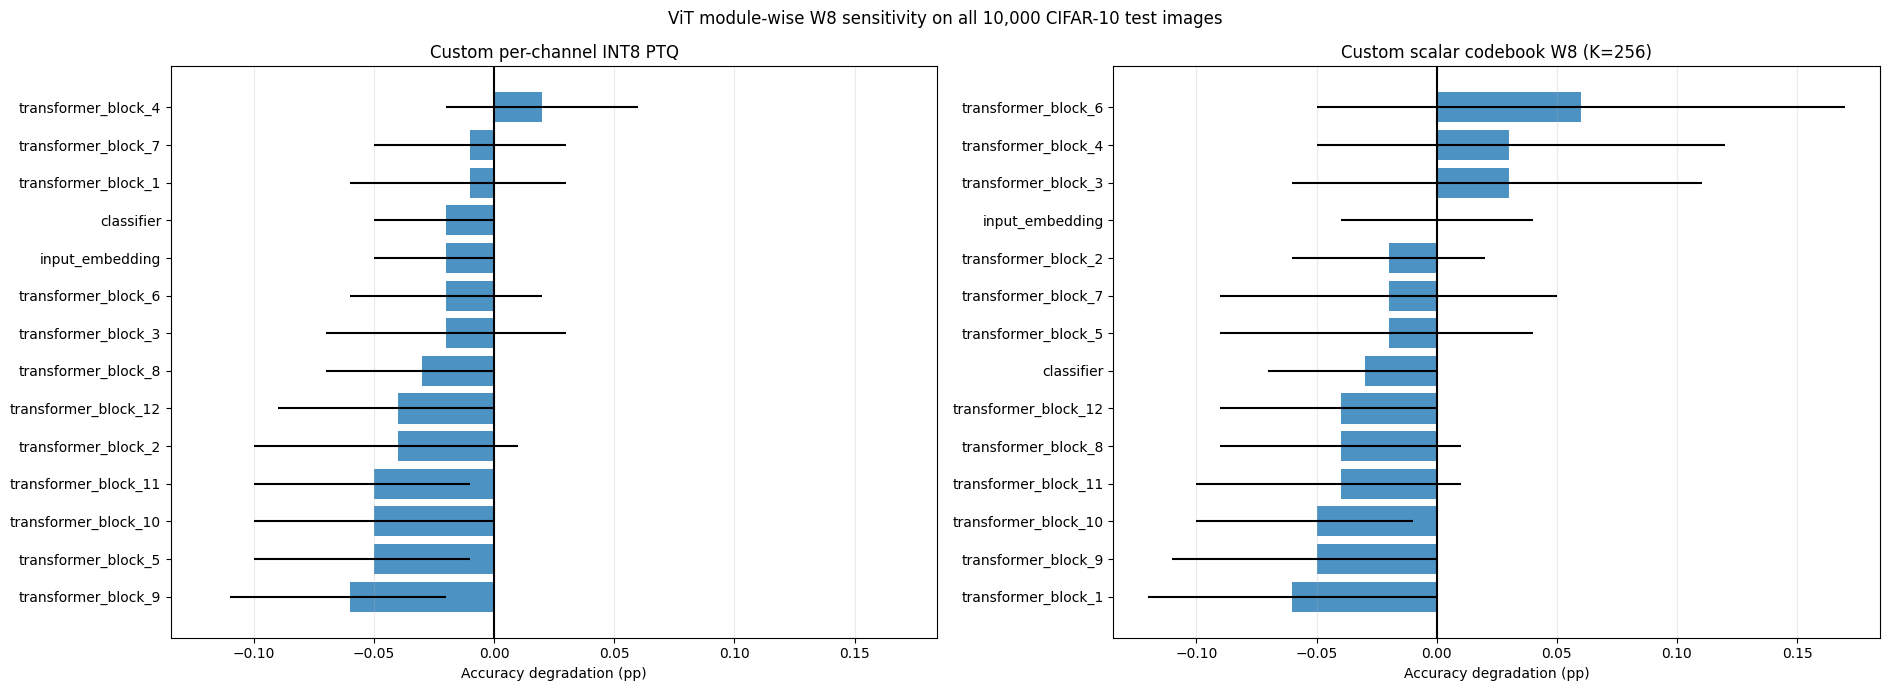

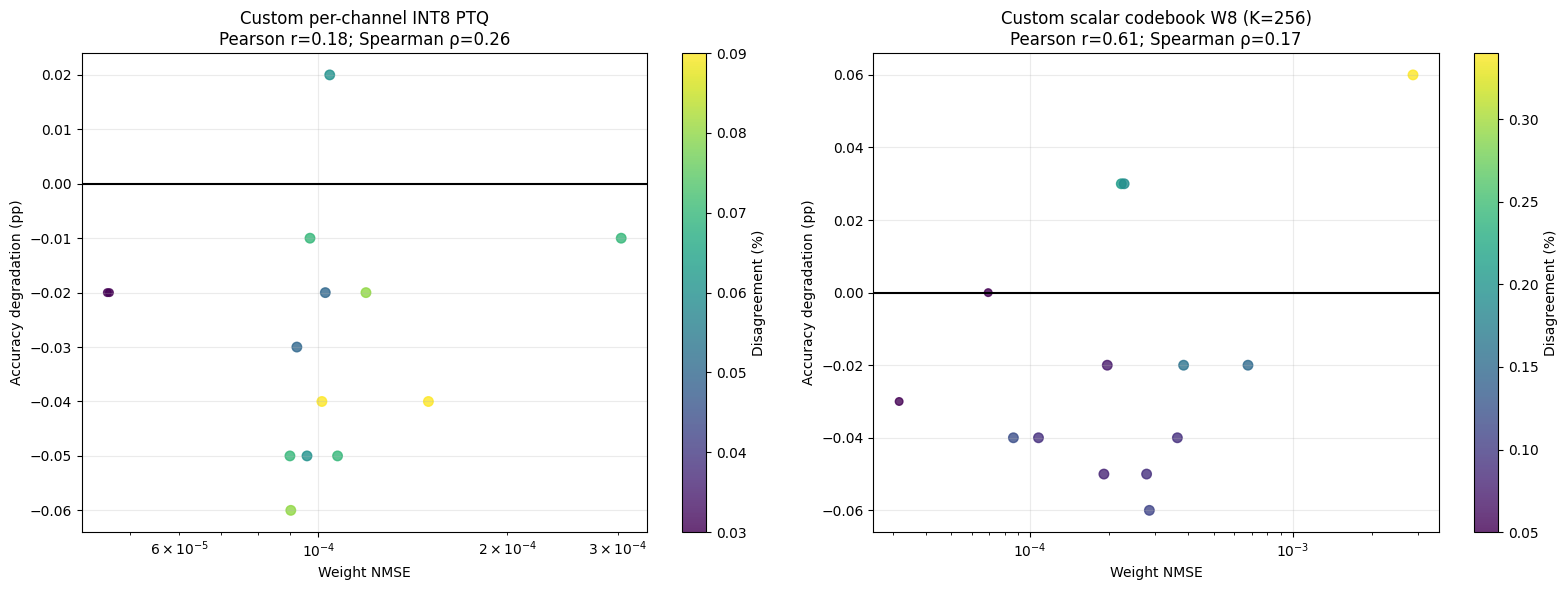

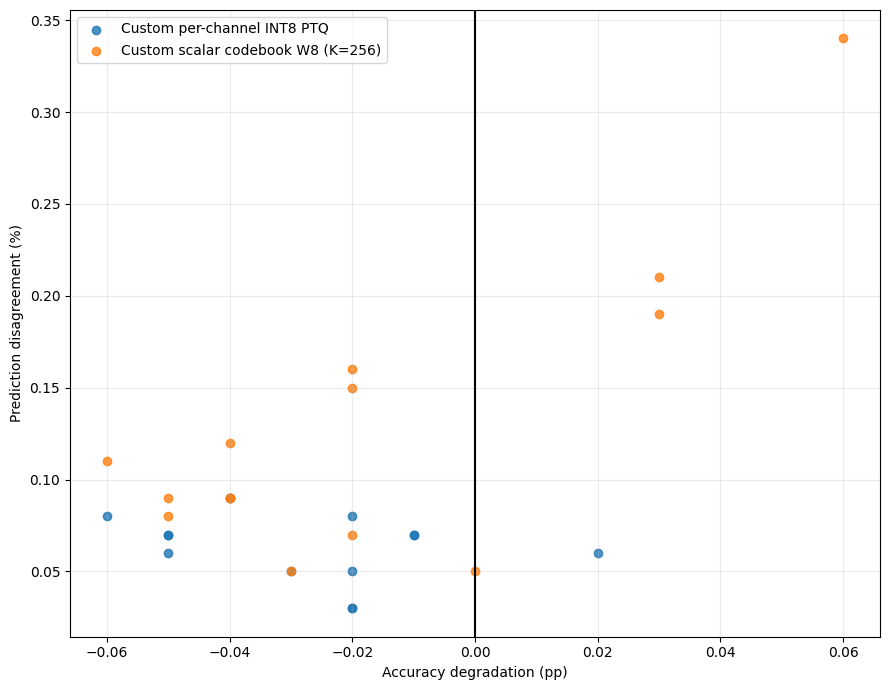

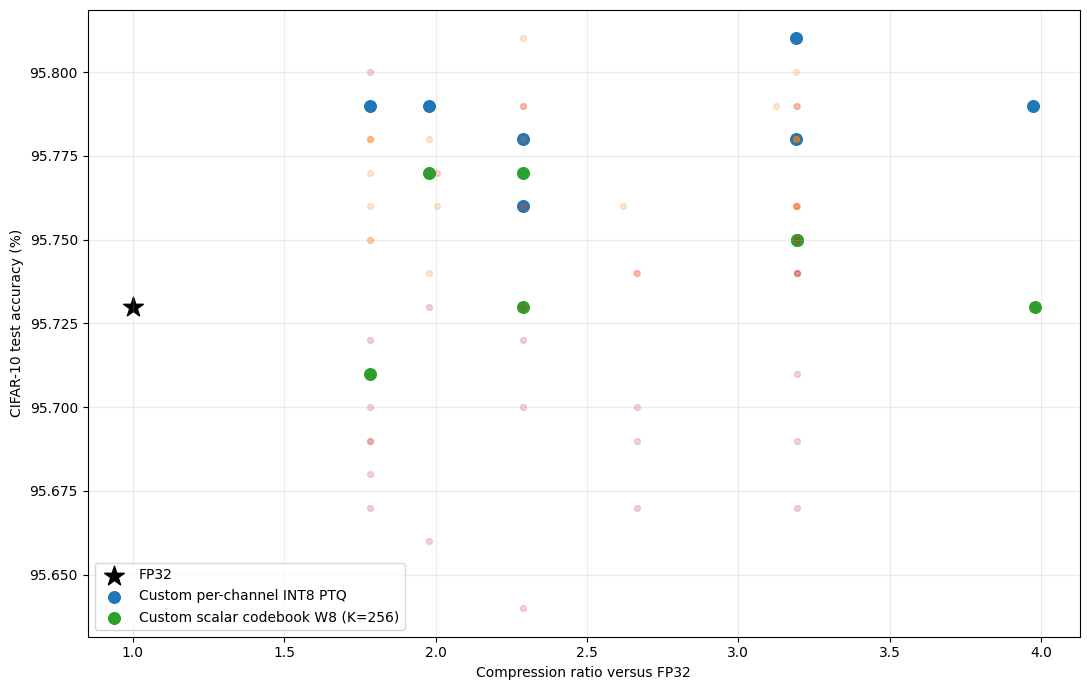

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(19, max(7, len(unit_names) * 0.5)), sharex=True)
for axis, (method, label) in zip(axes, METHODS.items()):
    group = ranked_results[ranked_results.method == method].sort_values("accuracy_degradation_pp")
    lower, upper = group.accuracy_degradation_pp - group.bootstrap_ci_low_pp, group.bootstrap_ci_high_pp - group.accuracy_degradation_pp
    axis.barh(group.analysis_unit, group.accuracy_degradation_pp, xerr=[lower, upper], alpha=0.8)
    axis.axvline(0, color="black"); axis.set_title(label); axis.set_xlabel("Accuracy degradation (pp)"); axis.grid(axis="x", alpha=0.25)
fig.suptitle(f"ViT {ANALYSIS_GRANULARITY}-wise W8 sensitivity on all 10,000 CIFAR-10 test images")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"figure1_{ANALYSIS_GRANULARITY}_sensitivity.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for axis, (method, label) in zip(axes, METHODS.items()):
    group = unit_results[unit_results.method == method]
    scatter = axis.scatter(group.weight_nmse, group.accuracy_degradation_pp, s=np.maximum(30, group.parameter_count / 150_000), c=group.prediction_disagreement_percent, cmap="viridis", alpha=0.8)
    corr = correlation_table[(correlation_table.method == method) & (correlation_table.error_metric == "weight_nmse") & (correlation_table.response_metric == "accuracy_degradation_pp")].iloc[0]
    axis.set_xscale("log"); axis.axhline(0, color="black"); axis.set_xlabel("Weight NMSE"); axis.set_ylabel("Accuracy degradation (pp)")
    axis.set_title(f"{label}\nPearson r={corr.pearson_r:.2f}; Spearman ρ={corr.spearman_rho:.2f}"); axis.grid(alpha=0.25); fig.colorbar(scatter, ax=axis, label="Disagreement (%)")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"figure2_{ANALYSIS_GRANULARITY}_error_vs_sensitivity.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(9, 7))
for method, label in METHODS.items():
    group = unit_results[unit_results.method == method]; axis.scatter(group.accuracy_degradation_pp, group.prediction_disagreement_percent, label=label, alpha=0.8)
axis.axvline(0, color="black"); axis.set_xlabel("Accuracy degradation (pp)"); axis.set_ylabel("Prediction disagreement (%)"); axis.legend(); axis.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"figure3_{ANALYSIS_GRANULARITY}_accuracy_vs_disagreement.png", dpi=180, bbox_inches="tight"); plt.show()

fig, axis = plt.subplots(figsize=(11, 7)); axis.scatter([1], [fp32_accuracy * 100], marker="*", s=220, color="black", label="FP32")
for method, label in METHODS.items():
    group = nonrandom_results[nonrandom_results.method == method]; axis.scatter(group.compression_ratio_vs_fp32, group.accuracy_percent, s=70, label=label)
    random_group = configuration_results[(configuration_results.method == method) & configuration_results.configuration.str.startswith("random_")]; axis.scatter(random_group.compression_ratio_vs_fp32, random_group.accuracy_percent, s=18, alpha=0.2)
axis.set_xlabel("Compression ratio versus FP32"); axis.set_ylabel("CIFAR-10 test accuracy (%)"); axis.legend(); axis.grid(alpha=0.25)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / f"figure4_{ANALYSIS_GRANULARITY}_accuracy_compression.png", dpi=180, bbox_inches="tight"); plt.show()

## 12. Save final tables and reproducibility record

In [16]:
ranked_results.to_csv(OUTPUT_DIR / f"final_ranked_{ANALYSIS_GRANULARITY}_sensitivity.csv", index=False)
candidate_table.to_csv(OUTPUT_DIR / "common_tensor_coverage.csv", index=False); unit_table.to_csv(OUTPUT_DIR / f"{ANALYSIS_GRANULARITY}_coverage.csv", index=False)
metadata = {
    "model_checkpoint": str(MODEL_PATH), "checkpoint_modified_time": MODEL_PATH.stat().st_mtime,
    "dataset": "CIFAR-10 official complete test split", "test_images": NUM_TEST_IMAGES,
    "preset": PRESET, "analysis_granularity": ANALYSIS_GRANULARITY,
    "meaningful_tensors": len(candidate_table), "analysis_units": len(unit_table),
    "candidate_policy": "kernels, embeddings and class token; attention biases excluded",
    "methods": METHODS, "ptq": {"bits": 8, "symmetric": True, "per_channel": PTQ_PER_CHANNEL},
    "codebook": {"assignment_bits": 8, "codebook_size": CODEBOOK_SIZE, "vector_dim": CODEBOOK_VECTOR_DIM, "dtype": str(CODEBOOK_DTYPE), "iterations": CODEBOOK_ITERATIONS},
    "bootstrap_repetitions": BOOTSTRAP_REPETITIONS, "random_control_repetitions": RANDOM_CONTROL_REPETITIONS, "top_k_values": TOP_K_VALUES,
    "activations_quantized": False, "fake_quantization_used": False,
    "selection_bias_warning": "Selective configurations are exploratory because ranking and evaluation use the same test split.",
    "tensorflow_version": tf.__version__, "keras_version": keras.__version__, "scipy_version": scipy.__version__,
    "python_version": sys.version, "hardware": platform.platform(), "cache_version": CACHE_VERSION,
}
(OUTPUT_DIR / f"run_metadata_{ANALYSIS_GRANULARITY}.json").write_text(json.dumps(metadata, indent=2, default=str))
print(f"All results saved under: {OUTPUT_DIR}")
print("Every accuracy and disagreement value used all 10,000 CIFAR-10 test images.")

All results saved under: /Users/sahil/Group Studies/Quantization-Group-Studies/artifacts/vit_full_layer_sensitivity
Every accuracy and disagreement value used all 10,000 CIFAR-10 test images.


## Interpretation rules

- Module sensitivity describes the joint perturbation of all kernels in that logical block; it is not an individual-tensor causal effect.
- Switch to tensor granularity only when individual Q/K/V/MLP effects are required and sufficient compute is available.
- Negative degradation is not proof of improved generalization, and individual effects cannot be added to predict full-model degradation.
- Reconstructed FP32 Keras execution does not establish integer/codebook runtime latency. Storage estimates include scale or codebook overhead.
- Selective protection is exploratory because the same test set determines and evaluates the ranking; use held-out training data for confirmatory selection.